In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
cfd = pd.read_excel("/Users/jcapo/cernbox/DUNE-IFIC/Experiments/ProtoDUNE-HD/CFD/ProtoDUNE-II Temperature Profiles Pumps Off CE Off.xlsx", names=["temp", "temp_err"], index_col=0)

In [5]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")

Initializing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.99sensor/s]


In [6]:
tgrad.calibrate(calibName="LAR2023_TREE_AVG")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.43sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  48%|████▊     | 23/48 [00:00<00:00, 108.34sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 83.92sensor/s] 

ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.56sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 83.50sensor/s]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_29238/2035089224.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.44sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  46%|████▌     | 22/48 [00:00<00:00, 105.64sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 103.76sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_29238/2035089224.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004


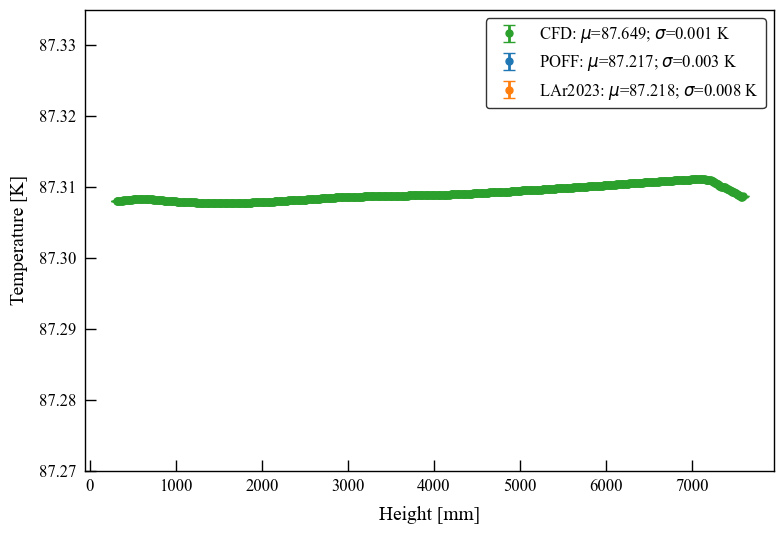

In [7]:
deltat = datetime.timedelta(minutes=60)
t2, color2 = pd.Timestamp("2024-5-2 7:21:00"), "tab:green"

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharex=True, sharey=True)
fig.set_size_inches(8, 5.5)
axes.errorbar(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - 0.34, yerr=cfd.loc[(1e3*cfd.index>300)]["temp_err"].values, fmt='o', label=fr'CFD: $\mu$={cfd.loc[(1e3*cfd.index>300)]["temp"].mean():.3f}; $\sigma$={cfd.loc[(1e3*cfd.index>300)]["temp"].std():.3f} K', color="tab:green")
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'POFF: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:blue")
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'LAr2023: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:orange")
axes.legend()
axes.set_xlabel("Height [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_ylim(87.27, 87.335)
fig.tight_layout()

In [8]:
ids = [
    39607, 39608, 39609, 39610, 39611, 39612, 39613, 39614, 39615, 39619, 39620, 39621, 39622, 39623, 39624, 39625, 39626, 39627,
    39644, 39645, 39646, 39647, 39648, 39649, 39628, 39629, 39630, 39657, 39658, 39659, 39664, 39665, 39666, 39660, 39661, 39667,
    39650, 39651, 39652, 39653, 39654, 39655, 40524, 40525, 40526, 40531, 40532, 40533
]

values = [
    40.5825, 23.3859, 36.2589, 29.5098, -0.559699, 48.8635, 37.7747, 16.2904, 29.2288, 16.9229, 67.1205, 62.7588, 23.0328, 25.1178, 3.52934, 30.4414, 52.1402, 50.4617,
    5.74219, 0, 5.71921, -9.84983, 5.52737, 19.3501, 20.0678, 55.4112, 8.26288, 27.5445, 14.5182, 5.27104, 61.4242, 41.1742, 18.3623, 46.3731, 24.5764, 72.9567,
    37.5261, 61.1882, 12.3265, -7.55886, 14.4194, 22.1062, 33.4424, 62.3633, 51.1519, 34.4214, 46.6191, 48.0297
]

lar_2018_tree_corr = pd.DataFrame({'CAL-ID': ids, 'cc': values}).set_index('CAL-ID')
lar_2018_tree_corr.index = lar_2018_tree_corr.index.astype(str)
lar_2018_tree_corr["cc_err"] = 3
lar_2018_tree_corr["cc"] = (lar_2018_tree_corr["cc"] - lar_2018_tree_corr["cc"].loc[(lar_2018_tree_corr.index=="40525")].values[0])
results = {"40525": lar_2018_tree_corr}

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_tree_readout_corr.pkl", "wb") as file:
    pickle.dump(results, file)

print(lar_2018_tree_corr)


               cc  cc_err
CAL-ID                   
39607  -21.780800       3
39608  -38.977400       3
39609  -26.104400       3
39610  -32.853500       3
39611  -62.922999       3
39612  -13.499800       3
39613  -24.588600       3
39614  -46.072900       3
39615  -33.134500       3
39619  -45.440400       3
39620    4.757200       3
39621    0.395500       3
39622  -39.330500       3
39623  -37.245500       3
39624  -58.833960       3
39625  -31.921900       3
39626  -10.223100       3
39627  -11.901600       3
39644  -56.621110       3
39645  -62.363300       3
39646  -56.644090       3
39647  -72.213130       3
39648  -56.835930       3
39649  -43.013200       3
39628  -42.295500       3
39629   -6.952100       3
39630  -54.100420       3
39657  -34.818800       3
39658  -47.845100       3
39659  -57.092260       3
39664   -0.939100       3
39665  -21.189100       3
39666  -44.001000       3
39660  -15.990200       3
39661  -37.786900       3
39667   10.593400       3
39650  -24.8

In [9]:
ids2 = [
    39607, 39608, 39609, 39610, 39611, 39612, 39613, 39614, 39615, 39619, 39620, 39621, 39622, 39623, 39624, 39625, 39626, 39627,
    39644, 39645, 39646, 39647, 39648, 39649, 39628, 39629, 39630, 39657, 39658, 39659, 39664, 39665, 39666, 39660, 39661, 39667,
    39650, 39651, 39652, 39653, 39654, 39655, 40524, 40525, 40526, 40531, 40532, 40533
]

values2 = [
    14.7383, -2.24692, 10.6261, 2.19245, -27.877, 21.5462, 10.4343, -11.1557, 1.7827, -9.0833, 41.1143, 36.7526, -1.78202, 0.302961, -21.2855, 3.91156, 25.6103, 23.9318,
    -19.2664, -25.0086, -12.3344, -33.5853, -18.2081, -4.38486, -5.8324, 29.511, -17.6373, 3.54204, -9.48429, -18.7314, 34.6272, 14.3772, -8.43454, 20.5521, -1.24464, 47.1356,
    12.1745, 35.8366, -13.0252, -30.4276, -8.69744, -0.984017, 8.78014, 37.7011, 26.4896, 17.543, 25.1913, 26.602
]

lar_2018_ref_corr = pd.DataFrame({'CAL-ID': ids2, 'cc': values2}).set_index('CAL-ID')
lar_2018_ref_corr.index = lar_2018_ref_corr.index.astype(str)
lar_2018_ref_corr["cc_err"] = 3
lar_2018_ref_corr["cc"] = (lar_2018_ref_corr["cc"] - lar_2018_ref_corr["cc"].loc[(lar_2018_ref_corr.index=="40525")].values[0])
results = {"40525": lar_2018_ref_corr}

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_readout_corr.pkl", "wb") as file:
    pickle.dump(results, file)

print(lar_2018_ref_corr)

               cc  cc_err
CAL-ID                   
39607  -22.962800       3
39608  -39.948020       3
39609  -27.075000       3
39610  -35.508650       3
39611  -65.578100       3
39612  -16.154900       3
39613  -27.266800       3
39614  -48.856800       3
39615  -35.918400       3
39619  -46.784400       3
39620    3.413200       3
39621   -0.948500       3
39622  -39.483120       3
39623  -37.398139       3
39624  -58.986600       3
39625  -33.789540       3
39626  -12.090800       3
39627  -13.769300       3
39644  -56.967500       3
39645  -62.709700       3
39646  -50.035500       3
39647  -71.286400       3
39648  -55.909200       3
39649  -42.085960       3
39628  -43.533500       3
39629   -8.190100       3
39630  -55.338400       3
39657  -34.159060       3
39658  -47.185390       3
39659  -56.432500       3
39664   -3.073900       3
39665  -23.323900       3
39666  -46.135640       3
39660  -17.149000       3
39661  -38.945740       3
39667    9.434500       3
39650  -25.5

In [10]:
ids3 = [
    39607, 39608, 39609, 39610, 39611, 39612, 39613, 39614, 39615, 39619, 39620, 39621, 39622, 39623, 39624, 39625, 39626, 39627,
    39644, 39645, 39646, 39647, 39648, 39649, 39628, 39629, 39630, 39657, 39658, 39659, 39664, 39665, 39666, 39660, 39661, 39667,
    39650, 39651, 39652, 39653, 39654, 39655, 40524, 40525, 40526, 40531, 40532, 40533
]

values3 = [
    10.2391, -2.45832, 1.3158, -2.30675, -28.0884, 12.236, 5.93508, -11.3671, -7.52758, -13.5825, 40.9029, 27.4424, -6.28122, 0.0915592, -30.5957, -0.587639, 25.3989, 14.6216,
    -23.7656, -25.22, -21.6446, -38.0845, -18.4195, -13.6951, -10.3316, 29.2996, -26.9475, -0.957159, -9.69569, -28.0417, 30.128, 14.1658, -17.7448, 16.0529, -1.45604, 37.8253,
    7.67532, 35.6252, -22.3355, -34.9268, -8.90884, -10.2943, 4.28095, 37.4897, 17.1793, 13.0438, 24.9799, 17.2917
]


lar_2018_ref_corr_alt = pd.DataFrame({'CAL-ID': ids3, 'cc': values3}).set_index('CAL-ID')
lar_2018_ref_corr_alt.index = lar_2018_ref_corr_alt.index.astype(str)
lar_2018_ref_corr_alt["cc_err"] = 3
lar_2018_ref_corr_alt["cc"] = (lar_2018_ref_corr_alt["cc"] - lar_2018_ref_corr_alt["cc"].loc[(lar_2018_ref_corr_alt.index=="40525")].values[0])
results = {"40525": lar_2018_ref_corr_alt}

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_readout_corr_alt.pkl", "wb") as file:
    pickle.dump(results, file)

print(lar_2018_ref_corr_alt)

               cc  cc_err
CAL-ID                   
39607  -27.250600       3
39608  -39.948020       3
39609  -36.173900       3
39610  -39.796450       3
39611  -65.578100       3
39612  -25.253700       3
39613  -31.554620       3
39614  -48.856800       3
39615  -45.017280       3
39619  -51.072200       3
39620    3.413200       3
39621  -10.047300       3
39622  -43.770920       3
39623  -37.398141       3
39624  -68.085400       3
39625  -38.077339       3
39626  -12.090800       3
39627  -22.868100       3
39644  -61.255300       3
39645  -62.709700       3
39646  -59.134300       3
39647  -75.574200       3
39648  -55.909200       3
39649  -51.184800       3
39628  -47.821300       3
39629   -8.190100       3
39630  -64.437200       3
39657  -38.446859       3
39658  -47.185390       3
39659  -65.531400       3
39664   -7.361700       3
39665  -23.323900       3
39666  -55.234500       3
39660  -21.436800       3
39661  -38.945740       3
39667    0.335600       3
39650  -29.8

In [11]:
lar2018 = pd.read_csv("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018TGRAD.csv", sep=";", header=0)
lar2018["CAL-ID"] = lar2018["CAL-ID"].astype(str)
lar2018 = lar2018.set_index("CAL-ID")
lar2018["POFF"] = 1e3*(lar2018["POFF"] - lar2018["POFF"].loc[(lar2018.index=="40525")].values[0])
lar2018 = lar2018["POFF"]
lar2018 = lar2018.to_frame()
lar2018["cc_err"] = 3
lar2018 = lar2018.rename(columns={"POFF": "cc"})
results = {"40525": lar2018}
print(results)

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_poff.pkl", "wb") as file:
    pickle.dump(results, file)

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2023/lar2023_tree_method_avg_path.pkl", "rb") as file:
    test = pickle.load(file)

print(test)


{'40525':                cc  cc_err
CAL-ID                   
39655  -53.421131       3
39654  -53.028100       3
39653  -83.289800       3
39652  -76.809900       3
39651  -14.052500       3
...           ...     ...
40263         NaN       3
40264         NaN       3
40265         NaN       3
40266         NaN       3
40267         NaN       3

[316 rows x 2 columns]}
{'40525':               cc    cc_err
39655 -45.648828  1.549934
39654 -51.408406  1.442169
39653 -76.074183  1.744827
39652 -45.637001  1.602043
39651  -7.150683  1.560242
39650 -30.382062  1.433481
40526 -17.085660  1.325038
40525  -0.000000  1.261940
40524 -25.291072  1.477202
39659 -59.677721  1.691510
39658 -43.016819  1.525149
39657 -35.577308  1.802645
39649 -39.925885  0.825858
39648 -56.282889  0.812188
39647 -67.641971  0.868684
39646 -48.423337  0.917356
39644 -57.303963  0.898087
39630 -59.659306  0.867851
39629  -8.818517  0.868788
39628 -46.511400  0.885257
39627 -18.344546  0.834133
39626 -14.102596  0.861

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.54sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  50%|█████     | 24/48 [00:00<00:00, 115.77sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 116.27sensor/s]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_29238/305903548.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.62sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG:  50%|█████     | 24/48 [00:00<00:00, 113.69sensor/s]

...

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.46sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  46%|████▌     | 22/48 [00:00<00:00, 107.07sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 111.72sensor/s]
/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_29238/305903548.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:08<00:00,  5.49sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2018_REF: 100%|██████████| 48/48 [00:00<00:00, 68.24sensor/s]

ERROR: SensorID (40530) not found in calibration (LAR2018_REF)
ERROR: SensorID (40529) not found in calibration (LAR2018_REF)



/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_29238/305903548.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004


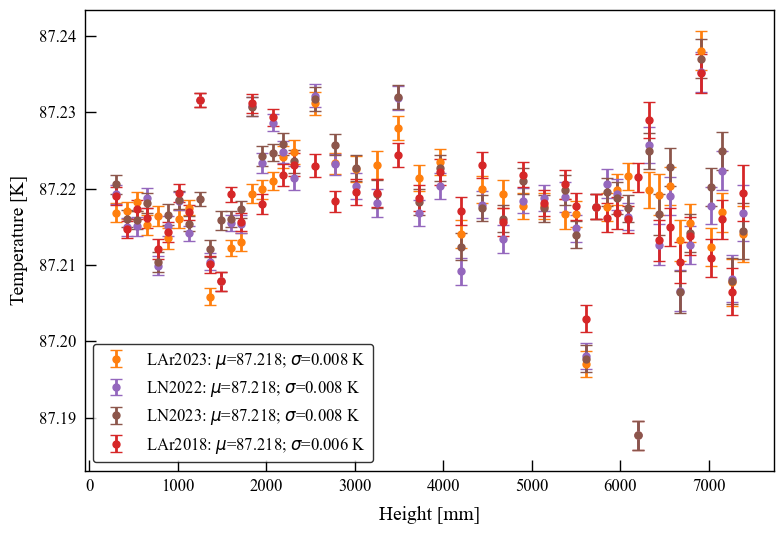

In [12]:
deltat = datetime.timedelta(minutes=60)
t2, color2 = pd.Timestamp("2024-5-2 7:21:00"), "tab:green"

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharex=True, sharey=True)
fig.set_size_inches(8, 5.5)
# axes.errorbar(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - 0.338, yerr=cfd.loc[(1e3*cfd.index>300)]["temp_err"].values, fmt='o', label=fr'CFD: $\mu$={cfd.loc[(1e3*cfd.index>300)]["temp"].mean():.3f}; $\sigma$={cfd.loc[(1e3*cfd.index>300)]["temp"].std():.3f} K', color="tab:green")
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'LAr2023: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:orange")
tgrad.calibrate(calibName="LN2022_TREE_AVG")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'LN2022: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:purple")
tgrad.calibrate(calibName="LN2023_TREE_AVG")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'LN2023: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:brown")
tgrad.calibrate(calibName="LAR2018_REF")
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'LAr2018: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:red")
axes.legend()
axes.set_xlabel("Height [mm]")
axes.set_ylabel("Temperature [K]")
# axes.set_ylim(87.27, 87.335)
fig.tight_layout()

In [4]:
with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_method.pkl", "rb") as file:
    lar2018_ref = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_tree_method.pkl", "rb") as file:
    lar2018_tree = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2023/lar2023_tree_method_avg_path.pkl", "rb") as file:
    lar2023_tree = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LN2023/ln2023_tree_method_avg_path.pkl", "rb") as file:
    ln2023_tree = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LN2022/ln2022_tree_method_avg_path.pkl", "rb") as file:
    ln2022_tree = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_tree_readout_corr.pkl", "rb") as file:
    lar2018_tree_corr = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_readout_corr.pkl", "rb") as file:
    lar2018_ref_corr = pickle.load(file)["40525"]

with open("/Users/jcapo/cernbox/RTDdata/calib/TGrad/LAR2018/lar2018_ref_readout_corr_alt.pkl", "rb") as file:
    lar2018_ref_corr_alt = pickle.load(file)["40525"]

Text(0.5, 1.0, 'Calibration Constants - 4 Calibration Campaigns')

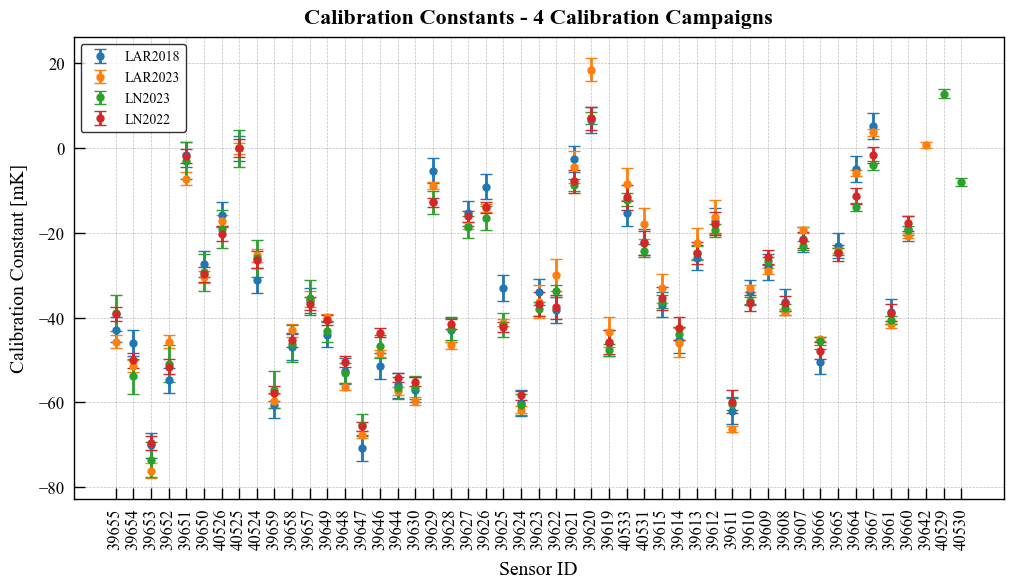

In [5]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))
# axes.errorbar(lar2018_ref.index.values, lar2018_ref["cc"].values, yerr=lar2018_ref["cc_err"].values, fmt='o', label='LAR2018 REF', color="tab:orange")
axes.errorbar(lar2018_ref.loc[(lar2018_ref.index.isin(lar2023_tree.index))].index.astype(str).values, lar2018_ref.loc[(lar2018_ref.index.isin(lar2023_tree.index))]["cc"].values, yerr=lar2018_ref.loc[(lar2018_ref.index.isin(lar2023_tree.index))]["cc_err"].values, fmt='o', label='LAR2018', color="tab:blue")
axes.errorbar(lar2023_tree.index.astype(str).values, lar2023_tree["cc"].values, yerr=lar2023_tree["cc_err"].values, fmt='o', label='LAR2023', color="tab:orange")
axes.errorbar(ln2023_tree.index.astype(str).values, ln2023_tree["cc"].values, yerr=ln2023_tree["cc_err"].values, fmt='o', label='LN2023', color="tab:green")
axes.errorbar(ln2022_tree.index.astype(str).values, ln2022_tree["cc"].values, yerr=ln2022_tree["cc_err"].values, fmt='o', label='LN2022', color="tab:red")
axes.legend(fontsize="small")
axes.tick_params(axis='x', rotation=90)
axes.set_xlabel("Sensor ID")
axes.set_ylabel("Calibration Constant [mK]")
axes.grid("on")
axes.set_title("Calibration Constants - 4 Calibration Campaigns")

In [9]:
# Join the dataframes by index, including cc and cc_err columns from each
df_joined = lar2018_ref[["cc", "cc_err"]].rename(columns={"cc": "lar2018", "cc_err": "lar2018_err"}).join(
    ln2022_tree[["cc", "cc_err"]].rename(columns={"cc": "ln2022", "cc_err": "ln2022_err"})
).join(
    ln2023_tree[["cc", "cc_err"]].rename(columns={"cc": "ln2023", "cc_err": "ln2023_err"})
).join(
    lar2023_tree[["cc", "cc_err"]].rename(columns={"cc": "lar2023", "cc_err": "lar2023_err"})
).dropna()
# df_joined.to_csv("df_joined.csv")

In [10]:
print(df_joined.head())

        lar2018  lar2018_err     ln2022  ln2022_err     ln2023  ln2023_err  \
CAL-ID                                                                       
39655     -42.8            3 -39.082496    1.715082 -38.924610    4.241804   
39654     -46.0            3 -50.081143    1.674786 -53.812167    4.144729   
39653     -70.1            3 -69.508784    1.680888 -73.488056    4.210271   
39652     -54.8            3 -51.570979    1.779347 -50.810694    4.294358   
39651      -1.5            3  -1.839558    1.749057  -2.929268    4.314392   

          lar2023  lar2023_err  
CAL-ID                          
39655  -45.648828     1.549934  
39654  -51.408406     1.442169  
39653  -76.074183     1.744827  
39652  -45.637001     1.602043  
39651   -7.150683     1.560242  


In [21]:
# Select only value columns
val_cols = [c for c in df_joined.columns if "_err" not in c]

# Get corresponding error columns in same order
err_cols = [c + "_err" for c in val_cols]

# Prepare results
outliers = pd.DataFrame(False, index=df_joined.index, columns=val_cols)

for idx, row in df_joined.iterrows():
    values = row[val_cols].values
    errors = row[err_cols].values

    # Weights: inverse variance
    weights = 1 / (errors ** 2)

    # Weighted median
    sort_idx = np.argsort(values)
    sorted_vals = values[sort_idx]
    sorted_weights = weights[sort_idx]
    cum_weights = np.cumsum(sorted_weights) / np.sum(sorted_weights)
    median_val = sorted_vals[np.searchsorted(cum_weights, 0.5)]

    # Weighted MAD
    mad = np.median(np.abs(values - median_val))

    # Robust z-score (using MAD)
    robust_z = np.abs(values - median_val) / (1.4826 * mad) if mad > 0 else np.zeros_like(values)

    # Mark outliers
    outliers.loc[idx] = robust_z > 3

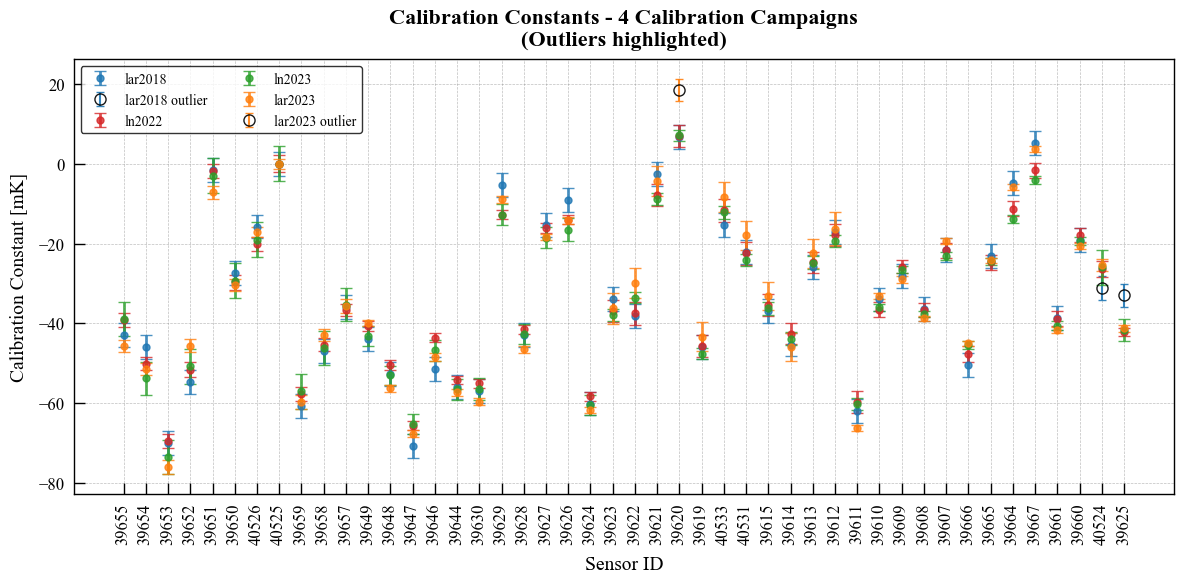

In [22]:
import matplotlib.pyplot as plt

# Keep the value and error columns
val_cols = [c for c in df_joined.columns if "_err" not in c]
err_cols = [c + "_err" for c in val_cols]
colors = {
    "lar2018": "tab:blue",
    "ln2022": "tab:red",
    "ln2023": "tab:green",
    "lar2023": "tab:orange"
}

fig, ax = plt.subplots(figsize=(12, 6))

for col, err_col in zip(val_cols, err_cols):
    # Normal points
    normal_mask = ~outliers[col]
    ax.errorbar(
        df_joined.index[normal_mask].astype(str),
        df_joined.loc[normal_mask, col],
        yerr=df_joined.loc[normal_mask, err_col],
        fmt='o',
        label=col,
        color=colors[col],
        markersize=5,
        alpha=0.8
    )

    # Outliers
    outlier_mask = outliers[col]
    ax.errorbar(
        df_joined.index[outlier_mask].astype(str),
        df_joined.loc[outlier_mask, col],
        yerr=df_joined.loc[outlier_mask, err_col],
        fmt='o',
        mfc='none',  # empty fill
        mec='black',  # black edge
        ecolor=colors[col],
        elinewidth=1.5,
        capsize=3,
        markersize=8,
        label=f"{col} outlier" if outlier_mask.any() else "",
        alpha=0.9
    )

ax.legend(fontsize="small", ncol=2)
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel("Sensor ID")
ax.set_ylabel("Calibration Constant [mK]")
ax.grid(True)
ax.set_title("Calibration Constants - 4 Calibration Campaigns\n(Outliers highlighted)")
plt.tight_layout()
plt.show()


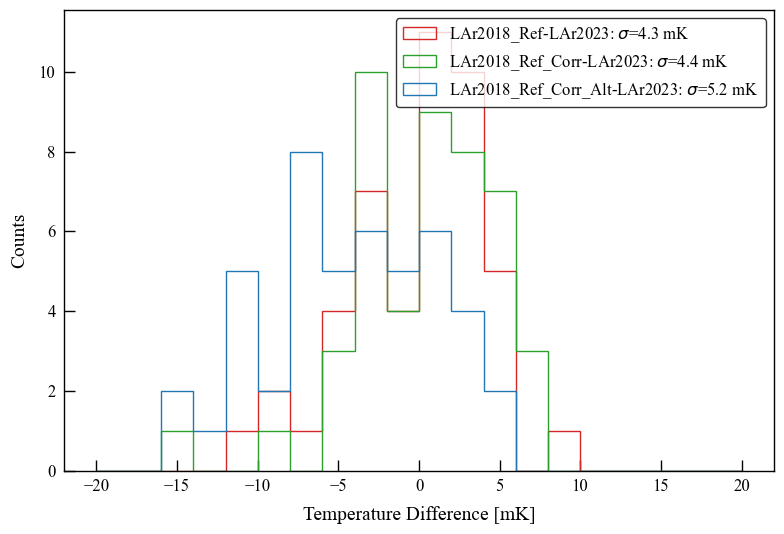

In [53]:
plt.figure(figsize=(8, 5.5))
# plt.hist((lar2018_tree["cc"]-lar2023_tree["cc"]).values, bins=20, histtype='step', label=fr"LAr2018-LAr2023: $\sigma$={np.std(lar2018_tree['cc']-lar2023_tree['cc']):.1f}", color="tab:blue", range=(-20, 20))
# plt.hist((lar2018_tree_corr["cc"]-lar2023_tree["cc"]).values, bins=20, histtype='step', label=fr"LAr2018_Corr-LAr2023: $\sigma$={np.std(lar2018_tree_corr['cc']-lar2023_tree['cc']):.1f}", color="tab:orange", range=(-20, 20))
plt.hist((lar2018_ref["cc"]-lar2023_tree["cc"]).values, bins=20, histtype='step', label=fr"LAr2018_Ref-LAr2023: $\sigma$={np.std(lar2018_ref['cc']-lar2023_tree['cc']):.1f} mK", color="tab:red", range=(-20, 20))
plt.hist((lar2018_ref_corr["cc"]-lar2023_tree["cc"]).values, bins=20, histtype='step', label=fr"LAr2018_Ref_Corr-LAr2023: $\sigma$={np.std(lar2018_ref_corr['cc']-lar2023_tree['cc']):.1f} mK", color="tab:green", range=(-20, 20))
plt.hist((lar2018_ref_corr_alt["cc"]-lar2023_tree["cc"]).values, bins=20, histtype='step', label=fr"LAr2018_Ref_Corr_Alt-LAr2023: $\sigma$={np.std(lar2018_ref_corr_alt['cc']-lar2023_tree['cc']):.1f} mK", color="tab:blue", range=(-20, 20))
plt.legend()
plt.xlabel("Temperature Difference [mK]")
plt.ylabel("Counts")
plt.tight_layout()